In [16]:
import pandas as pd
import numpy as np
import time

In [17]:
df = pd.read_csv("JC-201801-citibike-tripdata.csv")

In [18]:
df.head(20)

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender
0,932,2018-01-01 02:06:17.5410,2018-01-01 02:21:50.0270,3183,Exchange Place,40.716247,-74.033459,3199,Newport Pkwy,40.728745,-74.032108,31929,Subscriber,1992,1
1,550,2018-01-01 12:06:18.0390,2018-01-01 12:15:28.4430,3183,Exchange Place,40.716247,-74.033459,3199,Newport Pkwy,40.728745,-74.032108,31845,Subscriber,1969,2
2,510,2018-01-01 12:06:56.9780,2018-01-01 12:15:27.8100,3183,Exchange Place,40.716247,-74.033459,3199,Newport Pkwy,40.728745,-74.032108,31708,Subscriber,1946,1
3,354,2018-01-01 14:53:10.1860,2018-01-01 14:59:05.0960,3183,Exchange Place,40.716247,-74.033459,3267,Morris Canal,40.712419,-74.038526,31697,Subscriber,1994,1
4,250,2018-01-01 17:34:30.1920,2018-01-01 17:38:40.9840,3183,Exchange Place,40.716247,-74.033459,3639,Harborside,40.719252,-74.034234,31861,Subscriber,1991,1
5,613,2018-01-01 22:05:05.8740,2018-01-01 22:15:19.4190,3183,Exchange Place,40.716247,-74.033459,3203,Hamilton Park,40.727596,-74.044247,31859,Subscriber,1982,1
6,290,2018-01-02 12:13:51.7940,2018-01-02 12:18:42.1070,3183,Exchange Place,40.716247,-74.033459,3267,Morris Canal,40.712419,-74.038526,31694,Subscriber,1958,1
7,381,2018-01-02 12:50:03.3430,2018-01-02 12:56:24.6440,3183,Exchange Place,40.716247,-74.033459,3205,JC Medical Center,40.716540,-74.049638,31754,Subscriber,1989,2
8,318,2018-01-02 13:55:58.2430,2018-01-02 14:01:16.8810,3183,Exchange Place,40.716247,-74.033459,3275,Columbus Drive,40.718355,-74.038914,31816,Subscriber,1960,1
9,1852,2018-01-02 16:55:29.6390,2018-01-02 17:26:22.3050,3183,Exchange Place,40.716247,-74.033459,3281,Leonard Gordon Park,40.745910,-74.057271,31754,Subscriber,1976,1


In [19]:
mezczyzni = df[df['gender'] == 1]

In [20]:
kobiety = df[df['gender'] == 2]

In [21]:
nieokreslone = df[df['gender'] == 0]

In [22]:
total_seconds = (pd.to_datetime(df['stoptime']) - pd.to_datetime(df['starttime'])).dt.total_seconds()

In [23]:
czas = (pd.to_datetime(df['stoptime']) - pd.to_datetime(df['starttime'])).dt.components

In [24]:
czas

,days,hours,minutes,seconds,milliseconds,microseconds,nanoseconds
0,0,0,15,32,486,0,0
1,0,0,9,10,404,0,0
2,0,0,8,30,832,0,0
3,0,0,5,54,910,0,0
4,0,0,4,10,792,0,0
...,...,...,...,...,...,...,...
12672,0,0,4,7,882,0,0
12673,0,0,13,26,191,0,0
12674,0,0,24,59,640,0,0
12675,0,0,4,51,628,0,0


In [25]:
czas = pd.DataFrame(czas)

In [26]:
czas = czas.iloc[:, 0:4]

In [27]:
laczna = pd.concat([df, czas], axis = 1)

In [28]:
laczna["total_seconds"] = total_seconds

In [29]:
laczna

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,days,hours,minutes,seconds,total_seconds
0,932,2018-01-01 02:06:17.5410,2018-01-01 02:21:50.0270,3183,Exchange Place,40.716247,-74.033459,3199,Newport Pkwy,40.728745,-74.032108,31929,Subscriber,1992,1,0,0,15,32,932.486
1,550,2018-01-01 12:06:18.0390,2018-01-01 12:15:28.4430,3183,Exchange Place,40.716247,-74.033459,3199,Newport Pkwy,40.728745,-74.032108,31845,Subscriber,1969,2,0,0,9,10,550.404
2,510,2018-01-01 12:06:56.9780,2018-01-01 12:15:27.8100,3183,Exchange Place,40.716247,-74.033459,3199,Newport Pkwy,40.728745,-74.032108,31708,Subscriber,1946,1,0,0,8,30,510.832
3,354,2018-01-01 14:53:10.1860,2018-01-01 14:59:05.0960,3183,Exchange Place,40.716247,-74.033459,3267,Morris Canal,40.712419,-74.038526,31697,Subscriber,1994,1,0,0,5,54,354.910
4,250,2018-01-01 17:34:30.1920,2018-01-01 17:38:40.9840,3183,Exchange Place,40.716247,-74.033459,3639,Harborside,40.719252,-74.034234,31861,Subscriber,1991,1,0,0,4,10,250.792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12672,247,2018-01-31 11:03:59.1750,2018-01-31 11:08:07.0570,3640,Journal Square,40.733670,-74.062500,3201,Dey St,40.737711,-74.066921,31828,Subscriber,1962,1,0,0,4,7,247.882
12673,806,2018-01-31 15:34:36.8370,2018-01-31 15:48:03.0280,3640,Journal Square,40.733670,-74.062500,3211,Newark Ave,40.721525,-74.046305,31842,Subscriber,1987,1,0,0,13,26,806.191
12674,1499,2018-01-31 15:45:09.8000,2018-01-31 16:10:09.4400,3640,Journal Square,40.733670,-74.062500,3640,Journal Square,40.733670,-74.062500,29622,Subscriber,1981,1,0,0,24,59,1499.640
12675,291,2018-01-31 16:54:11.9480,2018-01-31 16:59:03.5760,3640,Journal Square,40.733670,-74.062500,3201,Dey St,40.737711,-74.066921,29622,Subscriber,1963,1,0,0,4,51,291.628


In [30]:
mezczyzni = laczna[laczna['gender'] == 1]

In [31]:
kobiety = laczna[laczna['gender'] == 2]

In [32]:
nieokreslone = laczna[laczna['gender'] == 0]

In [50]:
mezczyzni.head()

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,days,hours,minutes,seconds,total_seconds
0,932,2018-01-01 02:06:17.5410,2018-01-01 02:21:50.0270,3183,Exchange Place,40.716247,-74.033459,3199,Newport Pkwy,40.728745,-74.032108,31929,Subscriber,1992,1,0,0,15,32,932.486
2,510,2018-01-01 12:06:56.9780,2018-01-01 12:15:27.8100,3183,Exchange Place,40.716247,-74.033459,3199,Newport Pkwy,40.728745,-74.032108,31708,Subscriber,1946,1,0,0,8,30,510.832
3,354,2018-01-01 14:53:10.1860,2018-01-01 14:59:05.0960,3183,Exchange Place,40.716247,-74.033459,3267,Morris Canal,40.712419,-74.038526,31697,Subscriber,1994,1,0,0,5,54,354.910
4,250,2018-01-01 17:34:30.1920,2018-01-01 17:38:40.9840,3183,Exchange Place,40.716247,-74.033459,3639,Harborside,40.719252,-74.034234,31861,Subscriber,1991,1,0,0,4,10,250.792
5,613,2018-01-01 22:05:05.8740,2018-01-01 22:15:19.4190,3183,Exchange Place,40.716247,-74.033459,3203,Hamilton Park,40.727596,-74.044247,31859,Subscriber,1982,1,0,0,10,13,613.545


In [34]:
m_lacznie = np.sum(mezczyzni['total_seconds'])

In [35]:
k_lacznie = np.sum(kobiety['total_seconds'])

In [36]:
nieokreslone_lacznie = np.sum(nieokreslone['total_seconds'])

In [37]:
print(len(mezczyzni))
print(m_lacznie)
print(len(kobiety))
print(k_lacznie)
print(len(nieokreslone))
print(nieokreslone_lacznie)

9798
5319392.374
2451
1126109.064
428
321284.521


In [43]:
df_weather = pd.read_csv('pogoda_nowy_jork_styczen_2018.csv')

laczna['starttime'] = pd.to_datetime(laczna['starttime'])
df_weather['time'] = pd.to_datetime(df_weather['time'])

df_weather['time'] = df_weather['time'].dt.tz_localize(None)

laczna = laczna.sort_values('starttime')
df_weather = df_weather.sort_values('time')

Final = pd.merge_asof(
    laczna,
    df_weather,
    left_on='starttime',
    right_on='time',
    direction='backward' 
)

In [75]:
Final = Final.rename(columns={'temperature_2m (°C)': 'temperature (°C)', 
                      'relative_humidity_2m (%)': 'relative_humidity (%)',
                      'wind_speed_10m (km/h)': 'wind_speed (km/h)'}
                      )

In [76]:
Final.head()

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,...,days,hours,minutes,seconds,total_seconds,time,temperature (°C),relative_humidity (%),wind_speed (km/h),precipitation (mm)
0,132,2018-01-01 00:01:45.814,2018-01-01 00:03:58.4750,3186,Grove St PATH,40.719586,-74.043117,3211,Newark Ave,40.721525,...,0,0,2,12,132.661,2018-01-01 00:00:00,-12.8,51,16.8,0.0
1,560,2018-01-01 01:27:17.272,2018-01-01 01:36:37.8410,3276,Marin Light Rail,40.714584,-74.042817,3269,Brunswick & 6th,40.726012,...,0,0,9,20,560.569,2018-01-01 01:00:00,-13.1,54,16.3,0.0
2,294,2018-01-01 01:29:03.020,2018-01-01 01:33:57.8990,3195,Sip Ave,40.730743,-74.063784,3225,Baldwin at Montgomery,40.723659,...,0,0,4,54,294.879,2018-01-01 01:00:00,-13.1,54,16.3,0.0
3,197,2018-01-01 01:59:31.746,2018-01-01 02:02:48.9960,3211,Newark Ave,40.721525,-74.046305,3278,Monmouth and 6th,40.725685,...,0,0,3,17,197.250,2018-01-01 01:00:00,-13.1,54,16.3,0.0
4,932,2018-01-01 02:06:17.541,2018-01-01 02:21:50.0270,3183,Exchange Place,40.716247,-74.033459,3199,Newport Pkwy,40.728745,...,0,0,15,32,932.486,2018-01-01 02:00:00,-13.2,55,16.3,0.0


In [53]:
print(len(Final))
print(len(laczna))

12677
12677


In [56]:
Men = Final[Final['gender'] == 1]
Women = Final[Final['gender'] == 2]
Unknown = Final[Final['gender'] == 0]

In [57]:
print(len(Men))
print(len(Women))
print(len(Unknown))

9798
2451
428


In [62]:
Final.columns

Index(['tripduration', 'starttime', 'stoptime', 'start station id',
       'start station name', 'start station latitude',
       'start station longitude', 'end station id', 'end station name',
       'end station latitude', 'end station longitude', 'bikeid', 'usertype',
       'birth year', 'gender', 'days', 'hours', 'minutes', 'seconds',
       'total_seconds', 'time', 'temperature_2m (°C)',
       'relative_humidity_2m (%)', 'wind_speed_10m (km/h)',
       'precipitation (mm)'],
      dtype='object')

In [87]:
tlumacz_plci = {0: 'Unknown', 1: 'Man', 2: 'Woman'}
Final['gender'] = Final['gender'].map(tlumacz_plci)

In [121]:
Final_without_extreme_exceptions = Final[Final['total_seconds'] < (Final['total_seconds'].mean() * 5)]

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

In [117]:
print(Final_without_extreme_exceptions['gender'].unique())

['Man' 'Woman' 'Unknown']


<Axes: xlabel='total_seconds', ylabel='temperature (°C)'>

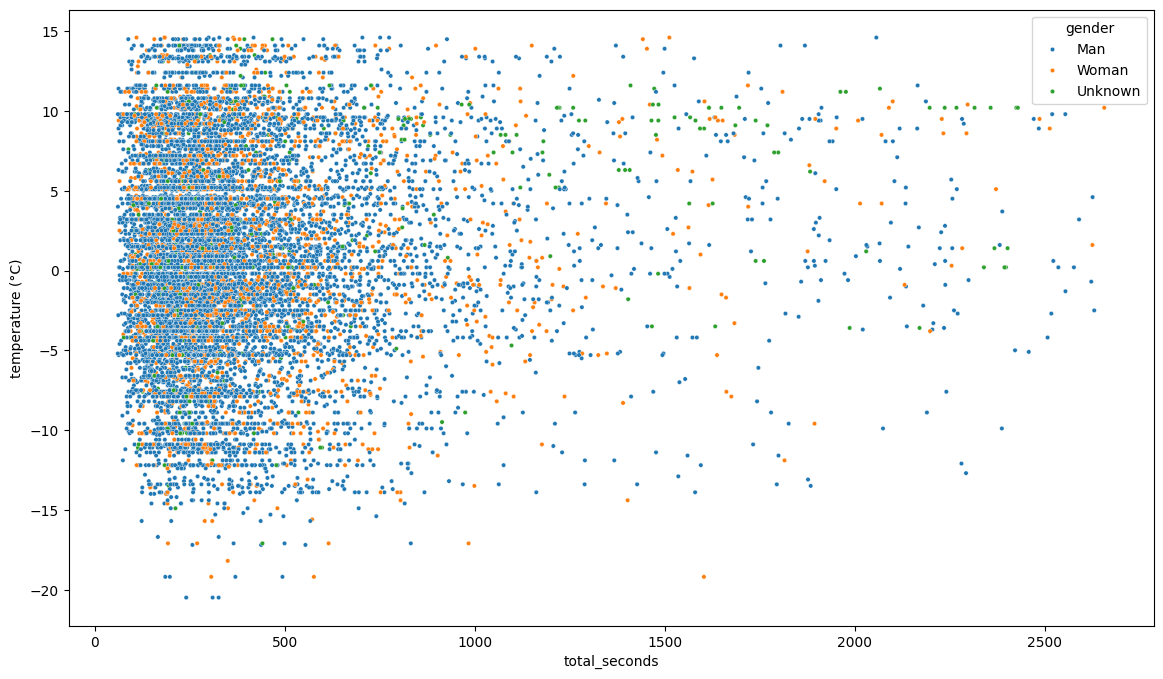

In [128]:
plt.figure(figsize=(14,8))
sns.scatterplot(
    x = 'total_seconds',
    y = 'temperature (°C)',
    data = Final_without_extreme_exceptions,
    hue = 'gender',
    s = 10
)

<Axes: xlabel='total_seconds', ylabel='temperature (°C)'>

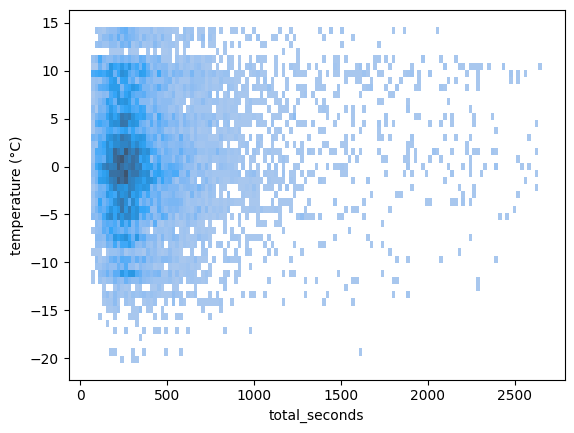

In [131]:
sns.histplot(
    x = 'total_seconds',
    y = 'temperature (°C)',
    data = Final_without_extreme_exceptions,
)

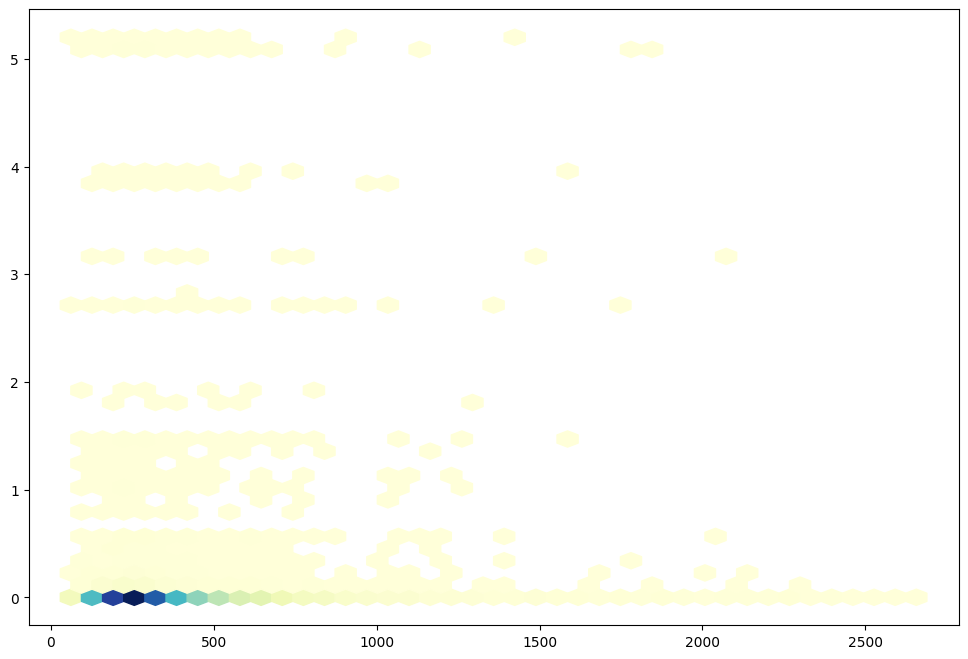

In [136]:
plt.figure(figsize=(12, 8))

# Używamy plt.hexbin zamiast scatterplot
hb = plt.hexbin(
    x=Final_without_extreme_exceptions['total_seconds'], 
    y=Final_without_extreme_exceptions['precipitation (mm)'], 
    gridsize=40,    # Liczba sześciokątów (im większa, tym drobniejsza siatka)
    cmap='YlGnBu',  # Ładna paleta kolorów (żółty-zielony-niebieski)
    mincnt=1        # Ignoruj strefy, w których nie ma ani jednego punktu
)

In [151]:
(nieokreslone['usertype'] == 'Subscriber').sum() / nieokreslone.shape[0]

np.float64(0.6565420560747663)

In [152]:
(mezczyzni['usertype'] == 'Subscriber').sum() / nieokreslone.shape[0]

np.float64(22.82943925233645)

In [153]:
(kobiety['usertype'] == 'Subscriber').sum() / nieokreslone.shape[0]

np.float64(5.700934579439252)